# Tutorial 3: Visualizing Data
------------------------------------------------------------------------------------

Pictures can tell the story much more efficiently than text, particularly showing relationships between variables. Surely, you have made many plots of data in the past using Excel or other (expensive) statistical software packages. The purpose of this tutorial is to enable you to use the powerful Python libraries which will create plots that represent the data in the best possible ways. 

## Learning Objectives
- Make plots with Matplotlib
- Make plots with Pandas

## Prerequisites
- Foundations in Python coding
- Pandas
- It will help if you are familiar with NumPy

## Getting Started
import the required libraries in the next code box.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Matplotlib
The main plotting set of libraries in Python is **Matplotlib** . It can do 2D and 3D plotting in "Matlab" style, and even [animate plots](https://matplotlib.org/stable/users/explain/animations/animations.html#sphx-glr-users-explain-animations-animations-py) (beyond the scope of this introduction). 

It is typical to import the libraries (matplotlib.pyplot) as plt to simplify it's use, much like we have been using np and pd as shorthand for NumPy and Pandas in this module. 

You could devote a whole course to [Matplotlib](https://matplotlib.org/stable/tutorials/index) as there are so many ways to plot but we will briefly cover mechanics and a few examples


## Making a plot with PyPlot

With Pyplot, we establish a figure, then annotate it and/or add all the necessary plotting elements. By default, the plot() function draws a line from point to point. 

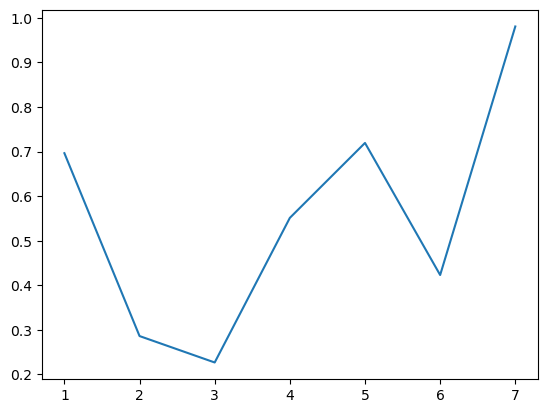

In [33]:
# Basic plotting 
np.random.seed(123)
x = np.arange(1,8)
y = np.random.rand(7)
plt.plot(x,y)

# Change the points to red circles
#plt.plot(x,y,"ro")

## Matplotlib Object Hierarchy
It might help you to have a mental map of how matplotlib organizes information to make the plot. Most of this is built into the pyplot module.

<img alt="Anatomy of a Matplotlib figure" src="https://matplotlib.org/stable/_images/anatomy.png" width="400" height="400">

At the top of the hierarchy is the **Figure** object, holding one or more **Axes**

Below that are individual lines, grids, legends and text boxes, ticks and labels

This gives us a fine granularity and level of control over the plot


### Adding to Plots
In plt.plot(), we can indicate line styles with a text string and add many chart elements

Text(0.5, 0, 'Day of Week (1=Monday)')

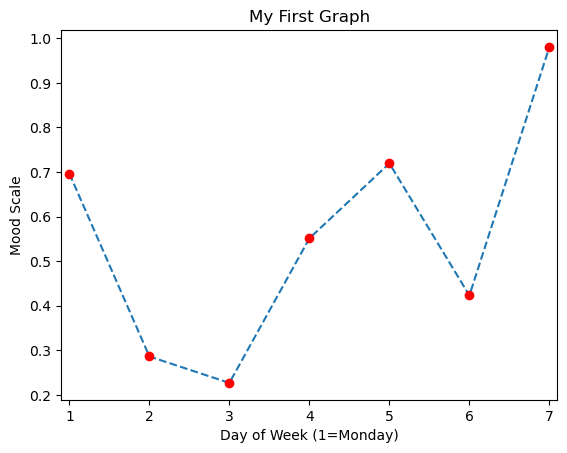

In [35]:
# axes look funny, change range?
fig = plt.figure()             #Create a figure, to which all parts need to be added
plt.title("My First Graph")    #Plot title
plt.xlim(0.9,7.1)                  #x axis range
plt.plot(x,y,"--")             #line style
plt.plot(x,y,"ro")             #point style and color
plt.ylabel("Mood Scale")       #Y axis label
plt.xlabel("Day of Week (1=Monday)") #X-axis label

There are many built-in marker options (far more than this short list)
<table>
    <tr>
        <th>Marker</th>
        <th>Description</th>
        <th>Marker</th>
        <th>Description</th>
    </tr>
    <tr>
        <td>o</td>
        <td>circle</td>
        <td>*</td>
        <td>star</td>
    </tr>
    <tr>
        <td>.</td>
        <td>point</td>
        <td>s</td>
        <td>square</td>     
    </tr>
    <tr>
        <td>x</td>
        <td>X</td>
        <td>D</td>
        <td>diamond</td>
    </tr>
    <tr>
        <td>'v'</td>
        <td>triangle down</td>
        <td>'^'</td>
        <td>triangle up</td>
    </tr>
</table>

You can also choose from standard colors:
![colors](https://matplotlib.org/stable/_images/sphx_glr_named_colors_001.png)'
<div class="alert alert-block alert-info"> <b>Tip:</b> Try using the color and symbol information to customize the plot above</a>. </div>

## Histograms
Histograms show us the overall distribution of numerical data

Use a histogram to display concentrations of sparsity of data points

(array([  2.,  26.,  45., 184., 213., 281., 157.,  53.,  32.,   7.]),
 array([ 7. ,  9.6, 12.2, 14.8, 17.4, 20. , 22.6, 25.2, 27.8, 30.4, 33. ]),
 <BarContainer object of 10 artists>)

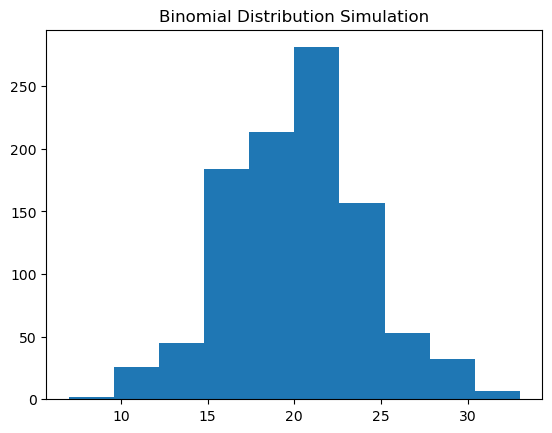

In [37]:
# Make a Histogram
np.random.seed(123)
binom = np.random.binomial(100,0.2,1000)
plt.figure()
plt.title("Binomial Distribution Simulation")
plt.hist(binom)

### Histogram Styles
We can add arguments to plt.hist() for different styles.
Check help for plt.hist() 

(array([  1.,   1.,   4.,  22.,  25.,  20.,  96.,  88., 102., 111., 190.,
         91.,  63.,  94.,  32.,  21.,  28.,   4.,   6.,   1.]),
 array([ 7. ,  8.3,  9.6, 10.9, 12.2, 13.5, 14.8, 16.1, 17.4, 18.7, 20. ,
        21.3, 22.6, 23.9, 25.2, 26.5, 27.8, 29.1, 30.4, 31.7, 33. ]),
 <BarContainer object of 20 artists>)

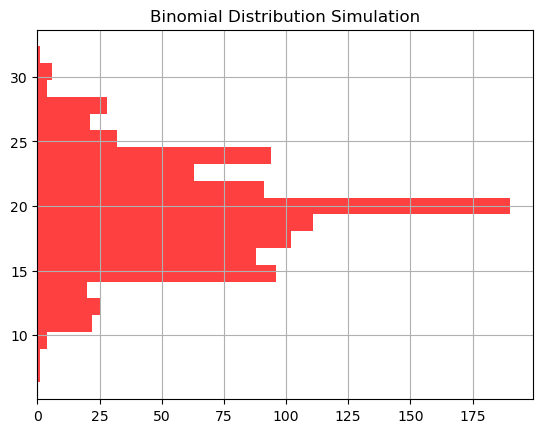

In [39]:
# Histogram with Various Arguments
plt.figure()
plt.title("Binomial Distribution Simulation")
plt.grid(True)
plt.hist(binom,bins=20, align="left",
         orientation = "horizontal",
         color="r",alpha=0.75)

### Plot Legends
Legends accessed with plt.legend()
We can use existing label arguments, or provide them. 

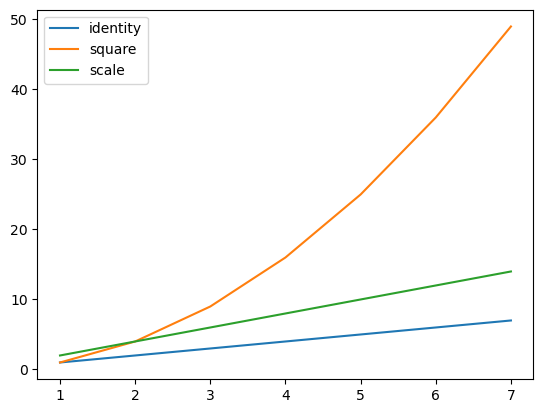

In [43]:
# Legend
plt.figure()
plt.plot(x,x,label="identity")
plt.plot(x,x**2,label="square")
plt.plot(x,x*2,label="scale")
plt.legend(loc="upper left")
#help(plt.legend)

## Histograms in Pandas

The central wrapper is DataFrame.plot()
The default value is line plots
You can change this with the kind argument: ‘bar’, ‘scatter’, ‘pie’ and others
You can also call hist directly 

In [45]:
# Import Dataframe
import os
file= "." + os.sep + "Data"
states = pd.read_csv(\data\states.csv")
states["Income_cat"] = pd.qcut(states.Income,3,labels=["low","med","high"])

# Histograms 
states.Income.plot(kind=“hist")
states.Income.hist(color='k', alpha=0.5, bins=50)

SyntaxError: invalid character '“' (U+201C) (257050279.py, line 6)

Pandas - Annotate Title
Set the blank canvas in order to annotate it.

## Density Plot

By changing the kind= argument we can get a density
We can also leverage the groupby functionality to get grouped plots

In [47]:
# Density Plot
states.Income.plot(kind='kde')

# Grouped Density
fig, ax = plt.subplots(figsize=(8,6))
for label, df in states.groupby('Income_cat'):
    df.Population.plot(kind="kde", ax=ax, label=label)
plt.legend()
plt.title("Population Distribution Across Income Categories")

NameError: name 'states' is not defined

Scatter Plot

The central wrapper is DataFrame.plot()
The default value is line plots
You can change this with the kind argument: ‘bar’, ‘scatter’, ‘pie’ and others

In [ ]:
# plot life expectancy versus illiteracy
states.plot(x="Life Exp",y="Illiteracy")
states.plot(x="Life Exp", y="Illiteracy", kind="scatter")

Scatter Plot Matrix

This is a popular way to view univariate and bivariate distributions
The diagonal is histograms, and the off diagonals are scatterplots of all variables. 

In [ ]:
# Scatter matrix
from pandas.plotting import scatter_matrix
scatter_matrix(states)
states.corr()

Test Your Knowledge

Write Python code to do the following:
Create a function to:
Load the mtcars datasest
Create a scatter plot showing avg mpg for each cylinder type
Label the x-axis: Cylinders
Label the y-axis: Avg. MPG

Subplots

Subplots allow us to combine multiple plots on to a single figure
Create a subplot using a figure and axes
Object-oriented approach enabling creation of more complex graphs

In [ ]:
For example, in this plot we:
Create three random time series
Define one figure
Define one axis
Create a stacked area chart
Add a legend, title and y-axis label


In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.stackplot(yrs, rng + rnd, labels=['Eastasia', 'Eurasia', 'Oceania'])
ax.set_title('Combined debt growth over time')
ax.legend(loc='upper left')
ax.set_ylabel('Total debt')

In [ ]:
Multiple Figures per Plot

In [ ]:
We can use plt.subplot() to establish subplots
Annotate the plots after the subplot call as normal

In [ ]:
# Multiple Figures Per Plot
x = np.arange(0,4*np.pi,0.01)
plt.figure()
plt.subplot(211)
plt.plot(x,np.sin(x),"k--")
plt.ylim(-1.2,1.2)
plt.subplot(212)
plt.plot(x,x**2,"b-")

# Save figure 
plt.savefig("myplot.png")

Multiple Subplots

We can also combine subplots with multiple axes

The code:

Generates a 1x2 figure or a Figure object and a NumPy array of axes
We then draw a scatter plot along the first axis and a histogram along the second

Subplot Customization

Matplotlib provides the gridspec module for even more customization
Combine with pyplot’s subplot2grid to create more extensive individual plot layouts 

Plotting a Surface

Plotting a 3d surface isn’t much different than 2d
You just need to account for the z-axis
Usually it helps to have a reference grid
And a few additional libraries
Unfortunately documentation is rather sparse at this point, although there is a decent amount of code to help get the point across
We’ll look at a few examples

In [27]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import numpy as np

fig = plt.figure()
ax = fig.gca(projection='3d')

TypeError: FigureBase.gca() got an unexpected keyword argument 'projection'

<Figure size 640x480 with 0 Axes>

Adding Color and Content

Plot the x, y, z coordinates with a little color
Add a color map to show differences in z coordinate
Use the plot_surface method to project your data onto the grid

In [ ]:
# Plot the surface
fig = plt.figure()
ax = fig.gca(projection="3d")
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
plt.show()

Customize the Axis

Set axes properties to adjust your plot

In [25]:
ax.set_zlim(-1.01, 1.01)
ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter(“%.02f”))

SyntaxError: invalid character '“' (U+201C) (763633419.py, line 3)

Add a Colorbar

Use a colorbar to give your customers a frame of reference

In [ ]:
fig.colorbar(surf, shrink=0.5, aspect=5)

3d Plot with Triangular Mesh

Our final plot shows how you can add surface features such as a triangular mesh to a plot
The plot_trisurf method accomplishes this

In [23]:
fig = plt.figure()
ax = fig.gca(projection=“3d”)

ax.plot_trisurf(x, y, z, linewidth=0.2, antialiased=True)

plt.show()

SyntaxError: invalid character '“' (U+201C) (651949887.py, line 2)

# Conclusion

You should now be able to make effective plots with Matplotlib. It might be nice, though to print a copy of the [Matplotlib cheatsheet](https://matplotlib.org/cheatsheets/_images/cheatsheets-1.png) now that you know how to use the syntax.

The next Tutorial will explore using [Inferential Statistics](./Submodule2_Tutorial4_InferentialStatistics.ipynb)


## Clean up
Remember to shut down your Jupyter Notebook instance when you are done for the day to avoid unnecessary charges. You can do this by stopping the notebook instance from the Cloud console.

# Answers

In [68]:
import pandas as pd

#get diabetes data and ead the file into a DataFrame
# Use \t as the delimiter for tab-separated values
diabetes = pd.read_csv("https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt", sep="\t")
# Display the DataFrame
print(diabetes.head())

   AGE  SEX   BMI     BP   S1     S2    S3   S4      S5  S6    Y
0   59    2  32.1  101.0  157   93.2  38.0  4.0  4.8598  87  151
1   48    1  21.6   87.0  183  103.2  70.0  3.0  3.8918  69   75
2   72    2  30.5   93.0  156   93.6  41.0  4.0  4.6728  85  141
3   24    1  25.3   84.0  198  131.4  40.0  5.0  4.8903  89  206
4   50    1  23.0  101.0  192  125.4  52.0  4.0  4.2905  80  135


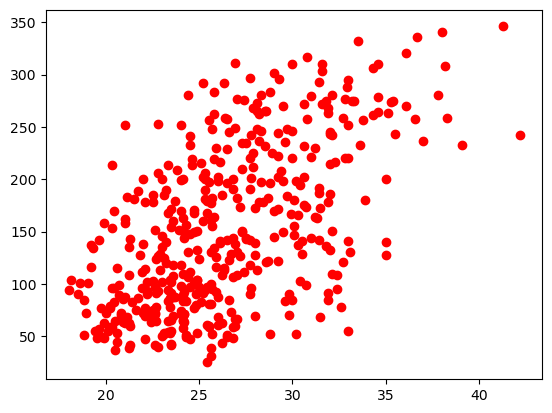

In [84]:
# Basic plotting 
#np.random.seed(123)
#x = np.arange(1,7)
#y = np.random.randn(6)
#plt.plot(diab2["BMI"],diab2["Y"])
plt.plot(diabetes["BMI"],diabetes["Y"],"ro")